<a href="https://colab.research.google.com/github/Pranaam19/Experiments/blob/main/Assignment(25/08/2026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer = fetch_ucirepo(id=14) #this refers to the exact Brest Cancer wisconsin DatasetNotFoundError

# data (as pandas dataframes)
X1 = breast_cancer.data.features
y1 = breast_cancer.data.targets

# metadata
print(breast_cancer.metadata)

# variable information
print(breast_cancer.variables)


{'uci_id': 14, 'name': 'Breast Cancer', 'repository_url': 'https://archive.ics.uci.edu/dataset/14/breast+cancer', 'data_url': 'https://archive.ics.uci.edu/static/public/14/data.csv', 'abstract': 'This breast cancer domain was obtained from the University Medical Centre, Institute of Oncology, Ljubljana, Yugoslavia. This is one of three domains provided by the Oncology Institute that has repeatedly appeared in the machine learning literature. (See also lymphography and primary-tumor.)', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 286, 'num_features': 9, 'feature_types': ['Categorical'], 'demographics': ['Age'], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1988, 'last_updated': 'Thu Mar 07 2024', 'dataset_doi': '10.24432/C51P4M', 'creators': ['Matjaz Zwitter', 'Milan Soklic'], 'intro_paper': None, 'additional_info': {'summary': 'Thi

In [ ]:
import pandas as pd
df = pd.concat([X1,y1 ], axis=1)

In [ ]:
# X = df.drop(columns='Diagnosis')
# y = df['Diagnosis']

In [ ]:
df.head()

,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat,Class
0,30-39,premeno,30-34,0-2,no,3,left,left_low,no,no-recurrence-events
1,40-49,premeno,20-24,0-2,no,2,right,right_up,no,no-recurrence-events
2,40-49,premeno,20-24,0-2,no,2,left,left_low,no,no-recurrence-events
3,60-69,ge40,15-19,0-2,no,2,right,left_up,no,no-recurrence-events
4,40-49,premeno,0-4,0-2,no,2,right,right_low,no,no-recurrence-events


In [ ]:
df.shape

(286, 10)

In [ ]:
df.isna().sum()

,0
age,0
menopause,0
tumor-size,0
inv-nodes,0
node-caps,8
deg-malig,0
breast,0
breast-quad,1
irradiat,0
Class,0


In [ ]:
#Correcting Null values for specific features
print(df['node-caps'].mode()[0])
print(df['breast-quad'].mode()[0])

no
left_low


In [ ]:
df['node-caps']= df['node-caps'].fillna((df['node-caps'].mode()[0]))
df['breast-quad']= df['breast-quad'].fillna((df['breast-quad'].mode()[0]))

In [ ]:
df.isna().sum()

,0
age,0
menopause,0
tumor-size,0
inv-nodes,0
node-caps,0
deg-malig,0
breast,0
breast-quad,0
irradiat,0
Class,0


In [ ]:
df.head()

,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat,Class
0,30-39,premeno,30-34,0-2,no,3,left,left_low,no,no-recurrence-events
1,40-49,premeno,20-24,0-2,no,2,right,right_up,no,no-recurrence-events
2,40-49,premeno,20-24,0-2,no,2,left,left_low,no,no-recurrence-events
3,60-69,ge40,15-19,0-2,no,2,right,left_up,no,no-recurrence-events
4,40-49,premeno,0-4,0-2,no,2,right,right_low,no,no-recurrence-events


In [ ]:
df['Class'].unique()

array(['no-recurrence-events', 'recurrence-events'], dtype=object)

In [ ]:
df.dtypes

,0
age,object
menopause,object
tumor-size,object
inv-nodes,object
node-caps,object
deg-malig,int64
breast,object
breast-quad,object
irradiat,object
Class,object


In [ ]:

X = df.drop(columns=['Class'])
y = df['Class']

In [ ]:
y_encoded = y.map({'recurrence-events': 1, 'no-recurrence-events': 0})

In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
dt_model = DecisionTreeClassifier(max_depth=4,  random_state=42)
dt_model.fit(X_train, y_train)
dt_train_preds = dt_model.predict(X_train)
dt_test_preds = dt_model.predict(X_test)



In [ ]:
lr_model = LogisticRegression(class_weight="balanced",max_iter=10000, random_state=42)
lr_model.fit(X_train_scaled, y_train) # Scaling is used for Logistic Regression because it's a distance-based algorithm and uses gradient descent, which is sensitive to feature scales.
lr_train_preds = lr_model.predict(X_train_scaled)
lr_test_preds = lr_model.predict(X_test_scaled)


In [ ]:

def calculate_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0)
    }

# Build structured comparison DataFrame
metrics_summary = pd.DataFrame({
    "Decision Tree (Train)": calculate_metrics(y_train, dt_train_preds),
    "Decision Tree (Test)": calculate_metrics(y_test, dt_test_preds),
    "Logistic Regression (Train)": calculate_metrics(y_train, lr_train_preds),
    "Logistic Regression (Test)": calculate_metrics(y_test, lr_test_preds)
})

In [ ]:


#CONFUSION MATRICES
dt_test_cm = confusion_matrix(y_test, dt_test_preds)
lr_test_cm = confusion_matrix(y_test, lr_test_preds)

print("=== MODEL PERFORMANCE METRICS ===")
print(metrics_summary)

print("\n=== DECISION TREE TESTING CONFUSION MATRIX ===")
print(dt_test_cm)

print("\n=== LOGISTIC REGRESSION TESTING CONFUSION MATRIX ===")
print(lr_test_cm)


=== SEPARATE MODEL PERFORMANCE METRICS ===
           Decision Tree (Train)  Decision Tree (Test)  \
Accuracy                0.830000              0.720930   
Precision               0.804878              0.545455   
Recall                  0.559322              0.461538   
F1-Score                0.660000              0.500000   

           Logistic Regression (Train)  Logistic Regression (Test)  
Accuracy                      0.725000                    0.616279  
Precision                     0.523256                    0.387097  
Recall                        0.762712                    0.461538  
F1-Score                      0.620690                    0.421053  

=== DECISION TREE TESTING CONFUSION MATRIX ===
[[50 10]
 [14 12]]

=== LOGISTIC REGRESSION TESTING CONFUSION MATRIX ===
[[41 19]
 [14 12]]


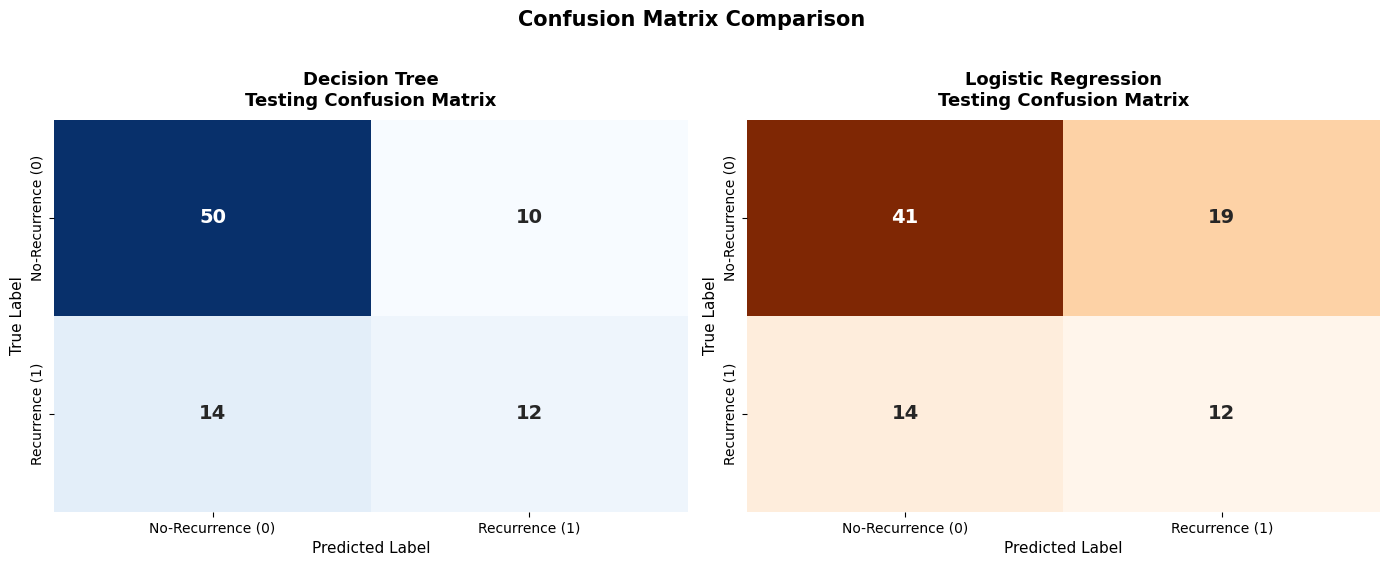

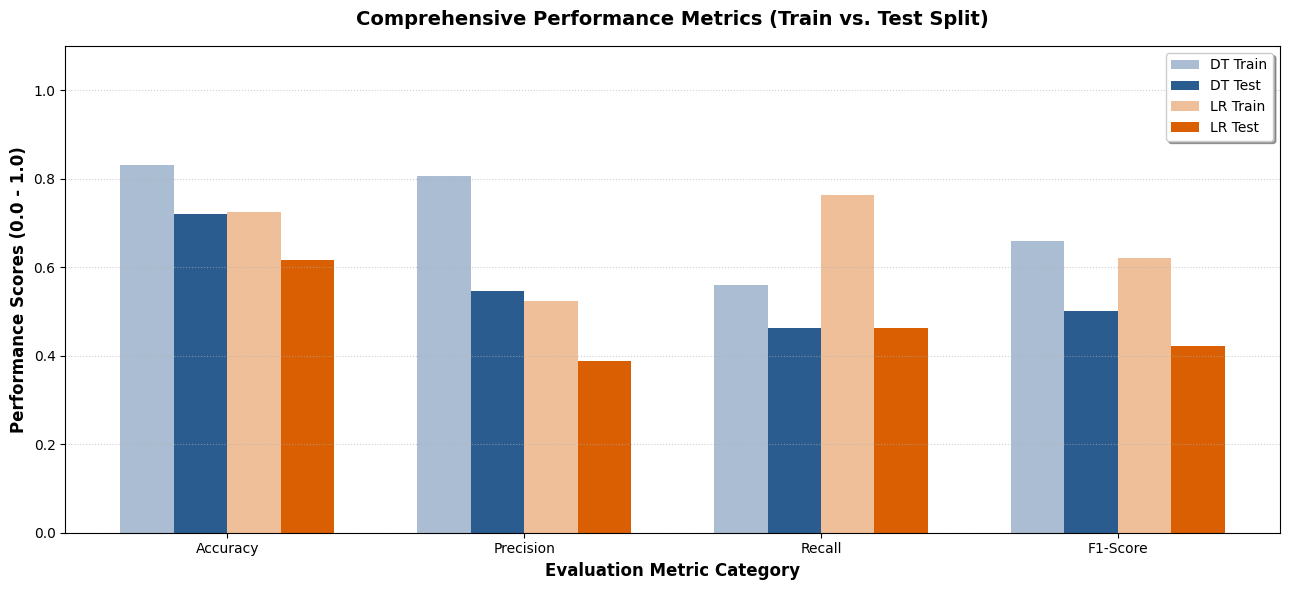

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns


labels = ['No-Recurrence (0)', 'Recurrence (1)']
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

#Decision Tree Confusion matrix Heatmap
sns.heatmap(dt_test_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=labels, yticklabels=labels, annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title('Decision Tree\nTesting Confusion Matrix', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# Logistic Regression Confusion Matrix Heatmap
sns.heatmap(lr_test_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False,
            xticklabels=labels, yticklabels=labels, annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('Logistic Regression\nTesting Confusion Matrix', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrix Comparison ', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


plot_df = metrics_summary.T

metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_list))
width = 0.18

plt.figure(figsize=(13, 6))


plt.bar(x - 1.5*width, plot_df.loc["Decision Tree (Train)"], width, label='DT Train', color='#2b5c8f', alpha=0.4)
plt.bar(x - 0.5*width, plot_df.loc["Decision Tree (Test)"], width, label='DT Test', color='#2b5c8f')
plt.bar(x + 0.5*width, plot_df.loc["Logistic Regression (Train)"], width, label='LR Train', color='#d95f02', alpha=0.4)
plt.bar(x + 1.5*width, plot_df.loc["Logistic Regression (Test)"], width, label='LR Test', color='#d95f02')

plt.xlabel('Evaluation Metric Category', fontsize=12, fontweight='bold')
plt.ylabel('Performance Scores (0.0 - 1.0)', fontsize=12, fontweight='bold')
plt.title('Comprehensive Performance Metrics (Train vs. Test Split)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(x, metrics_list)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()


In [ ]:
#Conclusion

#Decision Tree performed better when compared to Logistic Regression both interms of training and testing